In [1]:
# # weights
# !wget https://storage.googleapis.com/representations4d/checkpoints/pretrain_rvm_small16_256_204031069.npz

In [2]:
# @title Imports

import glob
import math
import random
import os
from icecream import ic

import cv2
import einops
from PIL import Image
import scipy.io as sio
import mediapy as media
import numpy as np
import pandas as pd
import queue
import seaborn as sns
import tensorflow as tf
import tqdm
import jax
import sklearn
import matplotlib.pyplot as plt
import cv2

I0000 00:00:1784613520.805274   26407 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784613520.846376   26407 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784613522.021511   26407 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
from models.rvm import *

In [4]:
model_variant = 'S'
model = VideoSiamMAE(
    tokenizer=Tokenizer(
        patch_embedding=PatchEmbedding(patch_size=[1, 16, 16], num_features=384),  # confirmed by checkpoint: encoder dim 384
        posenc=SincosPosEmb(base_token_shape=[16, 16]),
    ),
    encoder=Transformer.from_variant_str(variant_str=model_variant, dtype=jax.numpy.bfloat16),  # checkpoint confirms: 384 dim, 6 heads (kernel [384,6,64]), mlp 1536
    rnn_core=GatedTransformerCore(
        transformer=CrossAttentionTransformer(
            num_layers=4,
            num_heads=8,         # paper Table 5; if this errors, read true count off the error (see note)
            num_feats=384,
            mlp_dim=2048,        # ← THE FIX: checkpoint expects (384, 2048), flat value, not 4×dim
            dtype=jax.numpy.bfloat16,
        ),
        initializer=RandomStateInit(),
        token_dim=384,
        state_layer_norm=nn.LayerNorm(epsilon=0.0001, use_scale=True, use_bias=False),
    ),
    latent_emb_dim=384,
    # Decoder: fixed across all sizes — checkpoint confirms 512 dim, 16 heads (kernel [512,16,32]), mlp 2048
    decoder=CrossAttentionTransformer(
        num_layers=8,
        num_heads=16,
        num_feats=512,
        mlp_dim=2048,
        dtype=jax.numpy.bfloat16,
    ),
    decoder_embedder=nn.Dense(512),   # checkpoint confirms: kernel (384, 512)
    delta_embedder=nn.Dense(512),     # checkpoint confirms: kernel (64, 512) — delta is 64-dim Fourier-embedded upstream
    latent_posenc=SincosPosEmb(),
    detokenizer=Detokenizer(patch_size=(16, 16), num_features=3),  # checkpoint confirms: (512, 768) = 16·16·3
    decoder_emb_dim=512,
    masking_ratio=0.85,
)

def recover_tree(flat_dict):
  tree = {}
  for k, v in flat_dict.items():
    parts = k.split("/")
    node = tree
    for part in parts[:-1]:
      if part not in node:
        node[part] = {}
      node = node[part]
    node[parts[-1]] = v
  return tree

restored_params = recover_tree(np.load("/home/geometric-ssl/src/evals/ckpts/pretrain_rvm_small16_256_204031069.npz", allow_pickle=False))
count = sum([np.prod(v.shape) for v in jax.tree_util.tree_leaves(restored_params)])
print(f'number of params {model_variant} = {count}')

number of params S = 67480448


ic| source.shape: (1, 4, 256, 256, 3) <br>
    target.shape: (1, 4, 256, 256, 3) <br>
    target_deltas: np.array([4, 5, 6, 7]) 

In [1]:
rng_seed = 0
rng_key = {'default': jax.random.PRNGKey(rng_seed)}
@jax.jit
def forward(params, source, target, target_deltas):
    return model.apply(
        {'params': params},
        source, target, target_deltas,
        method=model.reconstruct,
        rngs=rng_key,
    )

NameError: name 'jax' is not defined

In [ ]:
cap = cv2.VideoCapture("/home/rvm/datasets/cycling.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = num_frames / fps

print(f"FPS: {fps}")
print(f"Frames: {num_frames}")
print(f"Duration: {duration:.2f} s")

# cap.release()

frames = []
at = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (256, 256))
    frame = frame/255.0
    # if at % 3 == 0:
    frames.append(frame)    
    at += 1

ic(len(frames))

FPS: 29.916666666666668
Frames: 307
Duration: 10.26 s


ic| len(frames): 307


307

vis frames

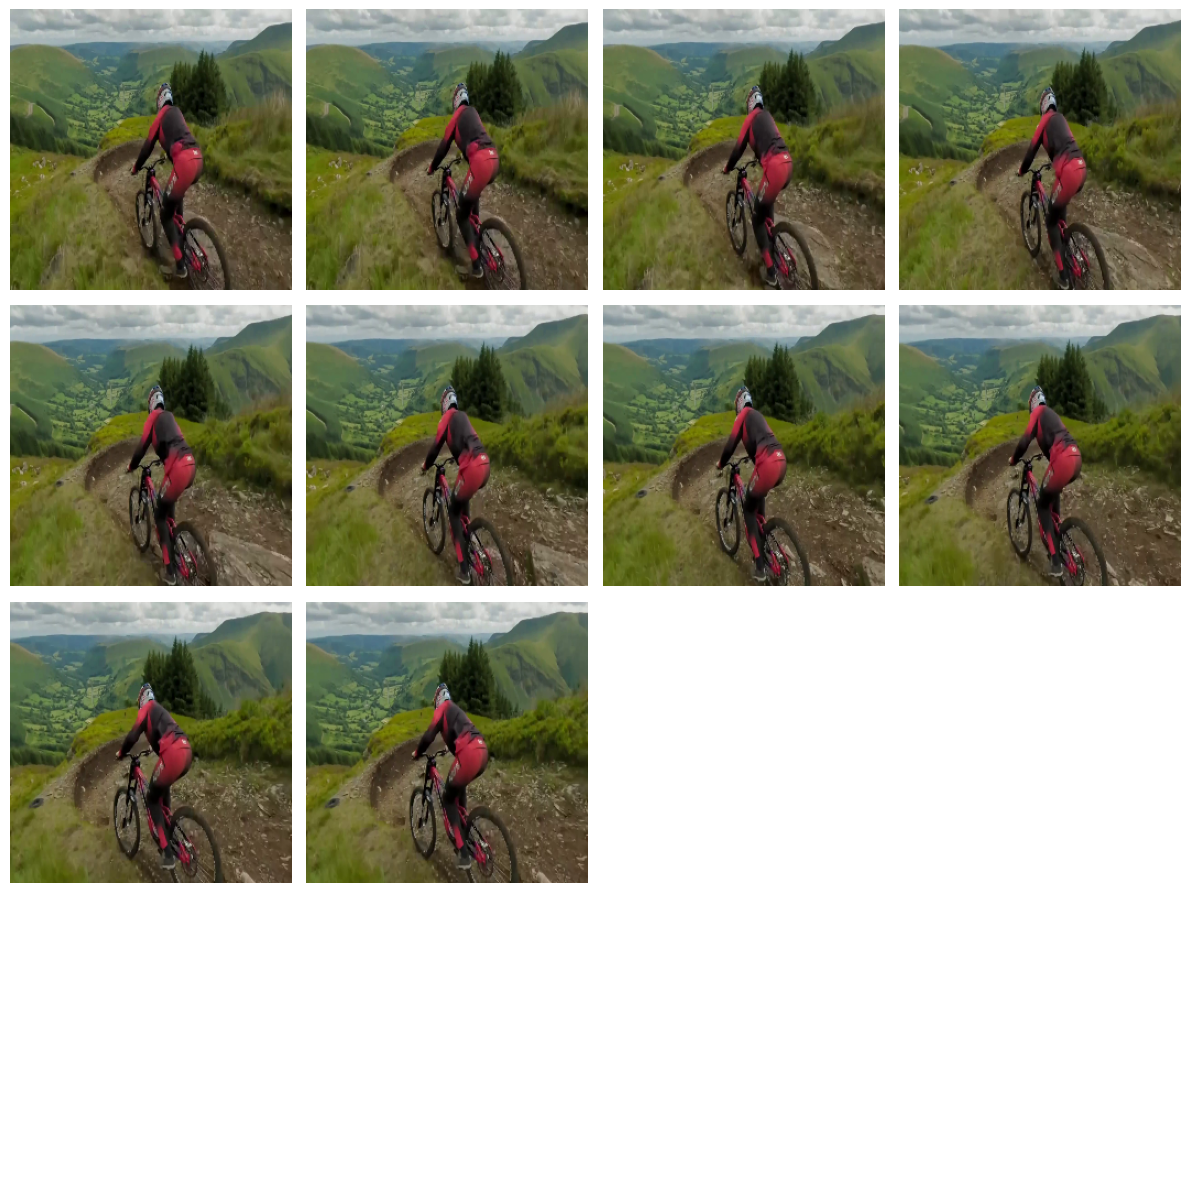

In [10]:
from vis_utils import plot_images
plot_images(frames, 10)

In [11]:
source_frames = np.array(frames[:4])[None, ...]
target_frames = np.array(frames[4:8])[None, ...]
ic(source_frames.shape, target_frames.shape)
# target_deltas = np.array([6, 7, 8, 9])
target_deltas = np.array([4, 5, 6, 7])

ic| source_frames.shape: (1, 4, 256, 256, 3)
    target_frames.shape: (1, 4, 256, 256, 3)


In [12]:
# src, target = np.random.random((1, 4, 256, 256, 3)), np.random.random((1, 4, 256, 256, 3))
# target_deltas = np.array([4, 5, 6, 7])

In [13]:
output = forward(restored_params, source_frames, target_frames, target_deltas)
recon = output['reconstructed']
image = recon[0, 0] 

2026-07-21 05:59:33.969576: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 05:59:33.969885: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 05:59:33.970514: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


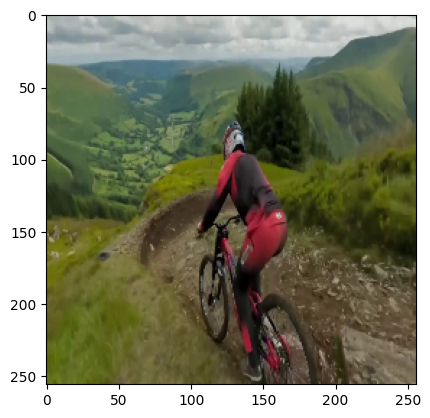

In [16]:
plt.imshow(frames[5])

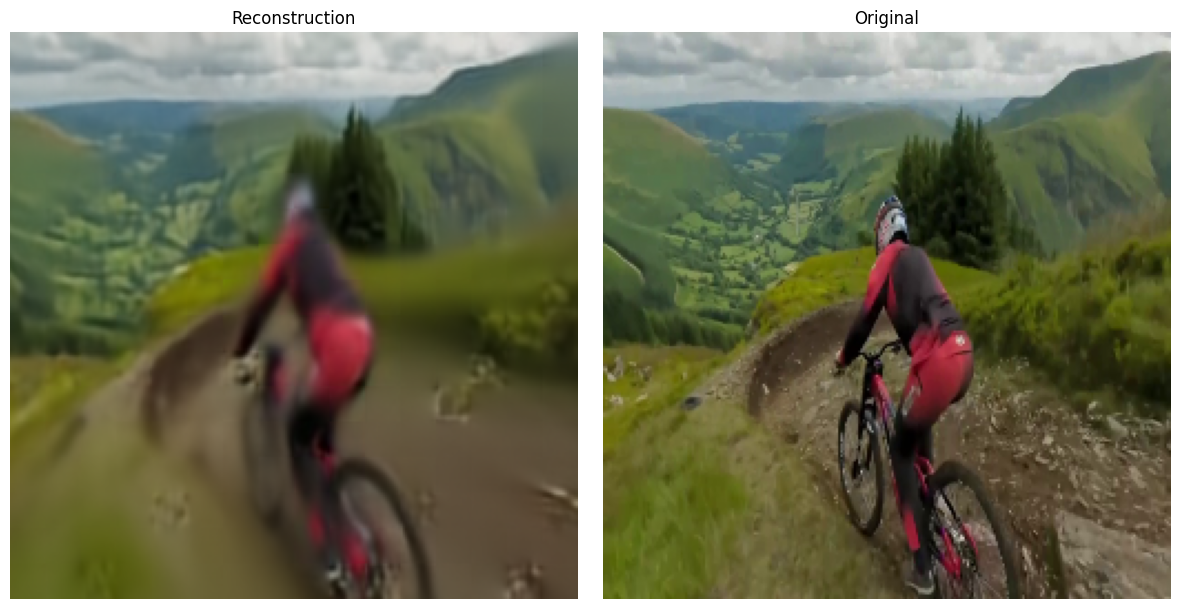

In [21]:
import matplotlib.pyplot as plt
import numpy as np

image = np.array(recon[0, 3])  # Convert JAX array to NumPy

plt.figure(figsize=(12, 6))

# Reconstructed image
plt.subplot(1, 2, 1)
plt.imshow(np.clip(image, 0, 1))
plt.title("Reconstruction")
plt.axis("off")

# Original image
plt.subplot(1, 2, 2)
plt.imshow(frames[5])
plt.title("Original")
plt.axis("off")

plt.tight_layout()
plt.show()